# Model Training Tests

In [1]:
# Libraries and functions
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score
from models import *


def preprocessing_input(x, labels, device='cpu', model='MLP'):
    """
    Preprocesses input data based on the model type and input dimensionality.

    Args:
        x (torch.Tensor): Input data tensor.
        labels (torch.Tensor): Target labels tensor.
        device (str): Device to move tensors to ('cpu' or 'cuda').
        model (nn.Module): The model instance.

    Returns:
        tuple: Processed input tensor and labels tensor moved to the specified device.
    """
    
    # Get the model name
    model_name = model.__class__.__name__

    # Preprocess input data based on the model type
    if model_name in ['CNN', 'ResNet9', 'LeNet5Flexible', 'ScalableCNN']:
        # CNNs and similar models expect 4D input tensors with shape (batch_size, channels, height, width)
        if x.dim() == 4:
            return x.to(device), labels.to(device)
        elif x.dim() == 3:  # Handle time series data by adding a channel dimension
            return x.unsqueeze(1).to(device), labels.to(device)
        elif x.dim() == 2:  # Handle tabular data by adding channel, height, and width dimensions
            return x.unsqueeze(1).unsqueeze(2).unsqueeze(3).to(device), labels.to(device)
        else:
            raise ValueError("For CNN-based models, expected a 4D tensor with shape (batch_size, channels, height, width).")
    
    elif model_name in ['MLP', 'LinearModel', 'ScalableMLP']:
        # MLPs and linear models expect 2D input tensors
        if x.dim() == 4:  # Flatten image data
            return x.view(x.size(0), -1).to(device), labels.to(device)
        elif x.dim() == 3:  # Time series data
            return x.view(x.size(0), x.size(1) * x.size(2)).to(device), labels.to(device)
        elif x.dim() == 2:  # Tabular data
            return x.to(device), labels.to(device)
        else:
            raise ValueError("For MLP/LinearModel, expected either 4D tensor (batch_size, channels, height, width) or 2D tensor (batch_size, num_features).")
    
    elif model_name in ['TransformerModelFlexible', 'MultiLayerLSTM']:
        # Transformers expect 3D input tensors with shape (batch_size, sequence_length, input_dim)
        if x.dim() == 4:  # Handle image data by flattening spatial dimensions
            batch_size, channels, height, width = x.size()
            x_flat = x.view(batch_size, channels * height * width).unsqueeze(2)  # Treat flattened image as a sequence
            return x_flat.to(device), labels.to(device)
        elif x.dim() == 3: # Time series data
            return x.to(device), labels.to(device)
        elif x.dim() == 2:  # Tabular data
            return x.unsqueeze(2).to(device), labels.to(device)  # Treat tabular as a sequence and 1 feature 
        else:
            raise ValueError("For TransformerModelFlexible, expected a 3D tensor (batch_size, sequence_length, input_dim), 4D tensor (batch_size, channels, height, width), or 2D tensor (batch_size, num_features).")
    
    else:
        raise ValueError(f"Unsupported model type: {model_name}")
    
def evaluate_test(model, test_loader, device='cpu'):
    model.eval()
    actuals, predictions = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = preprocessing_input(images, labels, device, model)
            outputs = model(images)
            
            if model.task_type == 'regression':
                labels = labels.float().view(-1, 1)
                predictions.append(outputs.cpu().numpy().flatten())
                actuals.append(labels.cpu().numpy().flatten())
            elif model.task_type == 'classification':
                labels = labels.long()
                predictions.append(outputs.cpu().numpy())
                actuals.append(labels.cpu().numpy())

    predictions = np.concatenate(predictions)
    actuals = np.concatenate(actuals)
    
    if model.task_type == 'regression':
        # Calculate regression metrics
        mse = mean_squared_error(actuals, predictions)
        r2 = r2_score(actuals, predictions)
        
        print(f' - Mean Squared Error: {mse:.4f}')
        print(f' - R² Score: {r2:.4f}')
        
        return mse, r2
    
    elif model.task_type == 'classification':
        if predictions.shape[1] == 1:
            # Binary classification (with only 1 output): use thresholding
            predicted_classes = (predictions > 0.5).astype(int).flatten()
            actual_classes = actuals.flatten()
        else:
            # Multi-class classification: apply argmax to get predicted classes
            predicted_classes = np.argmax(predictions, axis=1)
            actual_classes = actuals
            
        # Calculate classification metrics
        accuracy = accuracy_score(actual_classes, predicted_classes)
        precision = precision_score(actual_classes, predicted_classes, average='weighted')
        recall = recall_score(actual_classes, predicted_classes, average='weighted')
        f1 = f1_score(actual_classes, predicted_classes, average='weighted')
        
        print(f' - Accuracy: {accuracy:.4f}')
        print(f' - Precision: {precision:.4f}')
        print(f' - Recall: {recall:.4f}')
        print(f' - F1 Score: {f1:.4f}')
        
        return accuracy, precision, recall, f1

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, device='cpu'):
    best_model = None
    best_val_loss = float('inf')
    final_model = None
    metrics = {'loss': [], 'val_loss': []}
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = preprocessing_input(images, labels, device, model)  # Flatten the image according to its dimensionality
            
            if model.task_type == 'regression':
                labels = labels.float().view(-1, 1)  # Convert labels to float for regression
            elif model.task_type == 'classification':
                labels = labels.long()  # Ensure labels are in long format for classification
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
        
        # Calculate average training loss
        epoch_loss = running_loss / len(train_loader.dataset)
        metrics['loss'].append(epoch_loss)
        
        # Evaluate on the validation set
        val_loss = evaluate(model, val_loader, criterion, device=device)
        metrics['val_loss'].append(val_loss)
        
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}')
        
        # Check if this is the best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())  # Save the best model
    
    # Load the best model for return
    model.load_state_dict(best_model)
    
    return model, metrics

def evaluate(model, val_loader, criterion, device='cpu'):
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = preprocessing_input(images, labels, device, model)
            
            if model.task_type == 'regression':
                labels = labels.float().view(-1, 1)
            elif model.task_type == 'classification':
                labels = labels.long()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
    
    return val_loss / len(val_loader.dataset)

def plot_training_metrics(metrics, dataset):
    # Extract losses
    epochs = list(range(1, len(metrics['loss']) + 1))
    train_losses = metrics['loss']
    val_losses = metrics['val_loss']
    
    # Find the epoch with the minimum validation loss
    min_val_loss_epoch = val_losses.index(min(val_losses)) + 1
    min_val_loss = min(val_losses)
    
    # Create a plot
    plt.figure(figsize=(7, 4))
    sns.lineplot(x=epochs, y=train_losses, label='Training Loss')
    sns.lineplot(x=epochs, y=val_losses, label='Validation Loss')
    
    # Mark the minimum validation loss with a star
    plt.scatter(min_val_loss_epoch, min_val_loss, color='red', marker='*', s=200, label='Min Validation Loss')
    
    # Add titles and labels
    plt.title(f'Training and Validation Loss - {dataset.upper()}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Show the plot
    if not os.path.exists('./images'):
        os.makedirs('./images')
    plt.savefig(f'./images/{dataset}_training_loss.png')
    plt.show()

## 1) Linear Regressor

MPS is available


Training on MNIST dataset
Epoch [1/30], Loss: 0.4134, Val Loss: 0.3081
Epoch [2/30], Loss: 0.2978, Val Loss: 0.3005
Epoch [3/30], Loss: 0.2853, Val Loss: 0.2891
Epoch [4/30], Loss: 0.2769, Val Loss: 0.2875
Epoch [5/30], Loss: 0.2712, Val Loss: 0.2846
Epoch [6/30], Loss: 0.2667, Val Loss: 0.2919
Epoch [7/30], Loss: 0.2641, Val Loss: 0.2843
Epoch [8/30], Loss: 0.2622, Val Loss: 0.2948
Epoch [9/30], Loss: 0.2589, Val Loss: 0.2961
Epoch [10/30], Loss: 0.2580, Val Loss: 0.2947
Epoch [11/30], Loss: 0.2562, Val Loss: 0.2924
Epoch [12/30], Loss: 0.2544, Val Loss: 0.2891
Epoch [13/30], Loss: 0.2527, Val Loss: 0.2898
Epoch [14/30], Loss: 0.2514, Val Loss: 0.2935
Epoch [15/30], Loss: 0.2509, Val Loss: 0.2889
Epoch [16/30], Loss: 0.2484, Val Loss: 0.2951
Epoch [17/30], Loss: 0.2487, Val Loss: 0.2954
Epoch [18/30], Loss: 0.2482, Val Loss: 0.2964
Epoch [19/30], Loss: 0.2467, Val Loss: 0.3068
Epoch [20/30], Loss: 0.2447, Val Loss: 0.2973
Epoch [21/30], Loss: 0.2450, Val Loss: 0.308

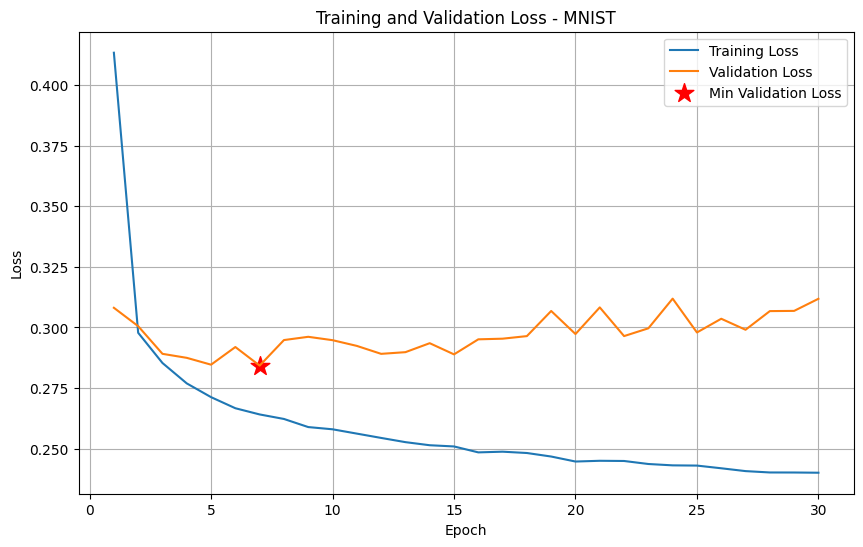

 - Accuracy: 0.9229
 - Precision: 0.9231
 - Recall: 0.9229
 - F1 Score: 0.9228


Training on CIFAR10 dataset
Epoch [1/30], Loss: 1.9820, Val Loss: 1.9650
Epoch [2/30], Loss: 1.9016, Val Loss: 2.0034
Epoch [3/30], Loss: 1.8719, Val Loss: 1.9421
Epoch [4/30], Loss: 1.8498, Val Loss: 1.9616
Epoch [5/30], Loss: 1.8446, Val Loss: 2.0107
Epoch [6/30], Loss: 1.8464, Val Loss: 1.9677
Epoch [7/30], Loss: 1.8335, Val Loss: 2.0678
Epoch [8/30], Loss: 1.8341, Val Loss: 2.0233
Epoch [9/30], Loss: 1.8213, Val Loss: 2.0420
Epoch [10/30], Loss: 1.8082, Val Loss: 2.0367
Epoch [11/30], Loss: 1.8152, Val Loss: 1.9751
Epoch [12/30], Loss: 1.8073, Val Loss: 2.0521
Epoch [13/30], Loss: 1.8069, Val Loss: 1.9746
Epoch [14/30], Loss: 1.7931, Val Loss: 1.9597
Epoch [15/30], Loss: 1.7946, Val Loss: 2.1184
Epoch [16/30], Loss: 1.7948, Val Loss: 1.9857
Epoch [17/30], Loss: 1.7925, Val Loss: 2.0631
Epoch [18/30], Loss: 1.7919, Val Loss: 2.0001
Epoch [19/30], Loss: 1.7855, Val Loss: 2.0340
Epoch [20/30], Loss: 1.782

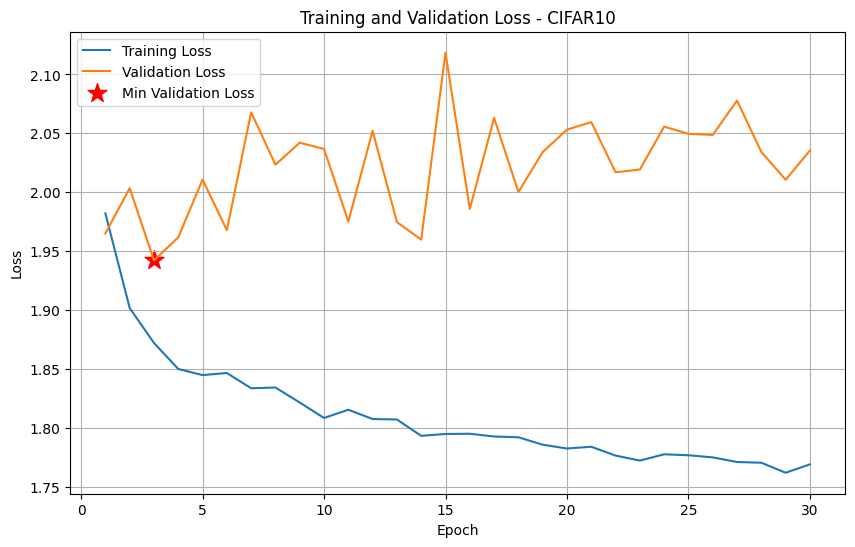

 - Accuracy: 0.3661
 - Precision: 0.3609
 - Recall: 0.3661
 - F1 Score: 0.3608


Training on AIRLINE dataset
Epoch [1/1000], Loss: 0.6164, Val Loss: 0.5718
Epoch [2/1000], Loss: 0.5810, Val Loss: 0.5552
Epoch [3/1000], Loss: 0.5484, Val Loss: 0.5406
Epoch [4/1000], Loss: 0.5193, Val Loss: 0.5281
Epoch [5/1000], Loss: 0.4939, Val Loss: 0.5176
Epoch [6/1000], Loss: 0.4710, Val Loss: 0.5085
Epoch [7/1000], Loss: 0.4510, Val Loss: 0.5010
Epoch [8/1000], Loss: 0.4334, Val Loss: 0.4948
Epoch [9/1000], Loss: 0.4187, Val Loss: 0.4898
Epoch [10/1000], Loss: 0.4048, Val Loss: 0.4851
Epoch [11/1000], Loss: 0.3935, Val Loss: 0.4803
Epoch [12/1000], Loss: 0.3829, Val Loss: 0.4754
Epoch [13/1000], Loss: 0.3733, Val Loss: 0.4705
Epoch [14/1000], Loss: 0.3647, Val Loss: 0.4662
Epoch [15/1000], Loss: 0.3568, Val Loss: 0.4626
Epoch [16/1000], Loss: 0.3502, Val Loss: 0.4593
Epoch [17/1000], Loss: 0.3436, Val Loss: 0.4548
Epoch [18/1000], Loss: 0.3375, Val Loss: 0.4492
Epoch [19/1000], Loss: 0.3317, Val L

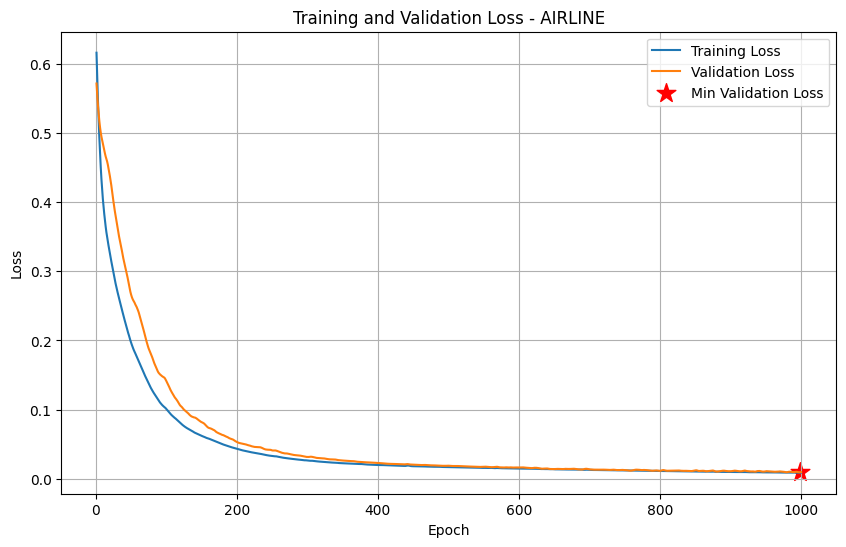

 - Mean Squared Error: 0.0395
 - R² Score: 0.8960


Training on ADULT dataset
Epoch [1/150], Loss: 0.4590, Val Loss: 0.3737
Epoch [2/150], Loss: 0.3492, Val Loss: 0.3478
Epoch [3/150], Loss: 0.3343, Val Loss: 0.3395
Epoch [4/150], Loss: 0.3283, Val Loss: 0.3347
Epoch [5/150], Loss: 0.3250, Val Loss: 0.3321
Epoch [6/150], Loss: 0.3230, Val Loss: 0.3302
Epoch [7/150], Loss: 0.3217, Val Loss: 0.3289
Epoch [8/150], Loss: 0.3208, Val Loss: 0.3281
Epoch [9/150], Loss: 0.3202, Val Loss: 0.3275
Epoch [10/150], Loss: 0.3198, Val Loss: 0.3274
Epoch [11/150], Loss: 0.3193, Val Loss: 0.3274
Epoch [12/150], Loss: 0.3193, Val Loss: 0.3271
Epoch [13/150], Loss: 0.3190, Val Loss: 0.3270
Epoch [14/150], Loss: 0.3191, Val Loss: 0.3271
Epoch [15/150], Loss: 0.3188, Val Loss: 0.3268
Epoch [16/150], Loss: 0.3187, Val Loss: 0.3269
Epoch [17/150], Loss: 0.3187, Val Loss: 0.3266
Epoch [18/150], Loss: 0.3186, Val Loss: 0.3268
Epoch [19/150], Loss: 0.3185, Val Loss: 0.3268
Epoch [20/150], Loss: 0.3184, Val Loss

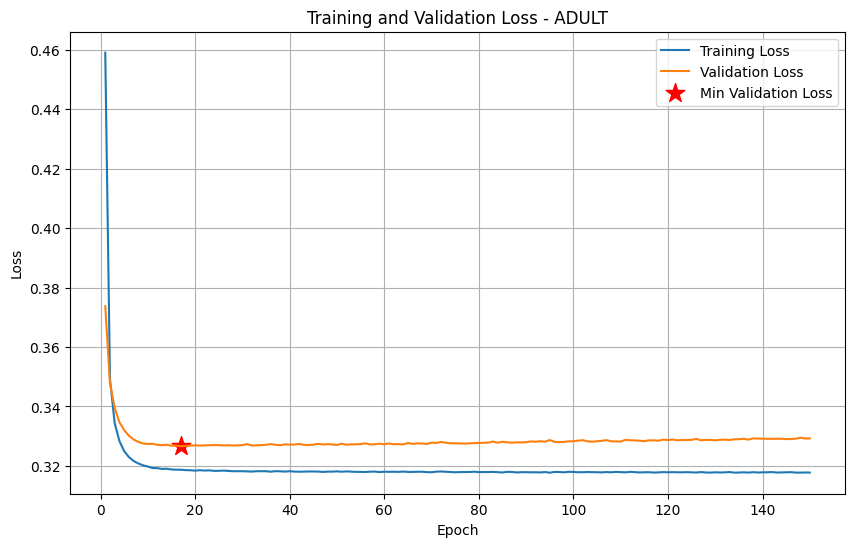

 - Accuracy: 0.8560
 - Precision: 0.8498
 - Recall: 0.8560
 - F1 Score: 0.8502


Training on LSST dataset
Epoch [1/150], Loss: 136.2344, Val Loss: 89.3043
Epoch [2/150], Loss: 82.5448, Val Loss: 72.1588
Epoch [3/150], Loss: 57.9089, Val Loss: 65.8874
Epoch [4/150], Loss: 41.6185, Val Loss: 63.4985
Epoch [5/150], Loss: 35.6014, Val Loss: 60.4745
Epoch [6/150], Loss: 35.8596, Val Loss: 61.7069
Epoch [7/150], Loss: 31.9998, Val Loss: 62.7661
Epoch [8/150], Loss: 31.1493, Val Loss: 47.7723
Epoch [9/150], Loss: 31.5514, Val Loss: 51.2273
Epoch [10/150], Loss: 25.1358, Val Loss: 45.6658
Epoch [11/150], Loss: 30.2567, Val Loss: 53.9523
Epoch [12/150], Loss: 24.6546, Val Loss: 60.2973
Epoch [13/150], Loss: 22.5563, Val Loss: 50.2312
Epoch [14/150], Loss: 18.6688, Val Loss: 48.7080
Epoch [15/150], Loss: 19.5932, Val Loss: 51.2646
Epoch [16/150], Loss: 18.3129, Val Loss: 57.6982
Epoch [17/150], Loss: 18.0486, Val Loss: 51.0969
Epoch [18/150], Loss: 14.6631, Val Loss: 56.9563
Epoch [19/150], Loss

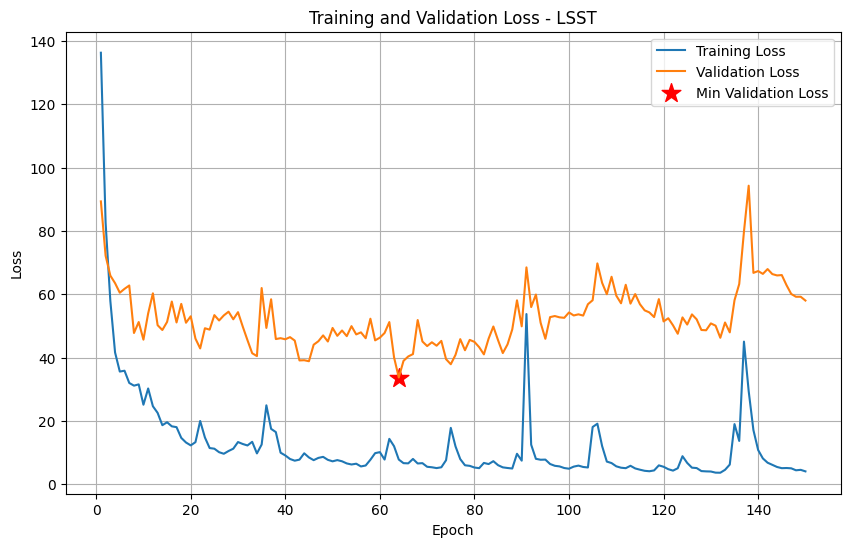

 - Accuracy: 0.2187
 - Precision: 0.3089
 - Recall: 0.2187
 - F1 Score: 0.2511


In [2]:
# Training loop
DATASETS = ['mnist', 'cifar10', 'airline', 'adult', 'LSST']
EPOCHS = [30,30,1000,150, 150]
BATCH_SIZE = 64
LEARNING_RATE = 0.001
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = LinearModel(dataset_name=dataset).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")


## 2) Multilayer Perceptron (MLP)

MPS is available


Training on MNIST dataset
Epoch [1/25], Loss: 0.2830, Val Loss: 0.1512
Epoch [2/25], Loss: 0.1192, Val Loss: 0.1117
Epoch [3/25], Loss: 0.0858, Val Loss: 0.0982
Epoch [4/25], Loss: 0.0632, Val Loss: 0.0968
Epoch [5/25], Loss: 0.0490, Val Loss: 0.0950
Epoch [6/25], Loss: 0.0400, Val Loss: 0.1037
Epoch [7/25], Loss: 0.0349, Val Loss: 0.0911
Epoch [8/25], Loss: 0.0289, Val Loss: 0.1066
Epoch [9/25], Loss: 0.0243, Val Loss: 0.1063
Epoch [10/25], Loss: 0.0230, Val Loss: 0.1145
Epoch [11/25], Loss: 0.0217, Val Loss: 0.1061
Epoch [12/25], Loss: 0.0201, Val Loss: 0.1319
Epoch [13/25], Loss: 0.0199, Val Loss: 0.1162
Epoch [14/25], Loss: 0.0160, Val Loss: 0.1329
Epoch [15/25], Loss: 0.0153, Val Loss: 0.1417
Epoch [16/25], Loss: 0.0136, Val Loss: 0.1186
Epoch [17/25], Loss: 0.0127, Val Loss: 0.1210
Epoch [18/25], Loss: 0.0169, Val Loss: 0.1285
Epoch [19/25], Loss: 0.0131, Val Loss: 0.1325
Epoch [20/25], Loss: 0.0116, Val Loss: 0.1325
Epoch [21/25], Loss: 0.0130, Val Loss: 0.127

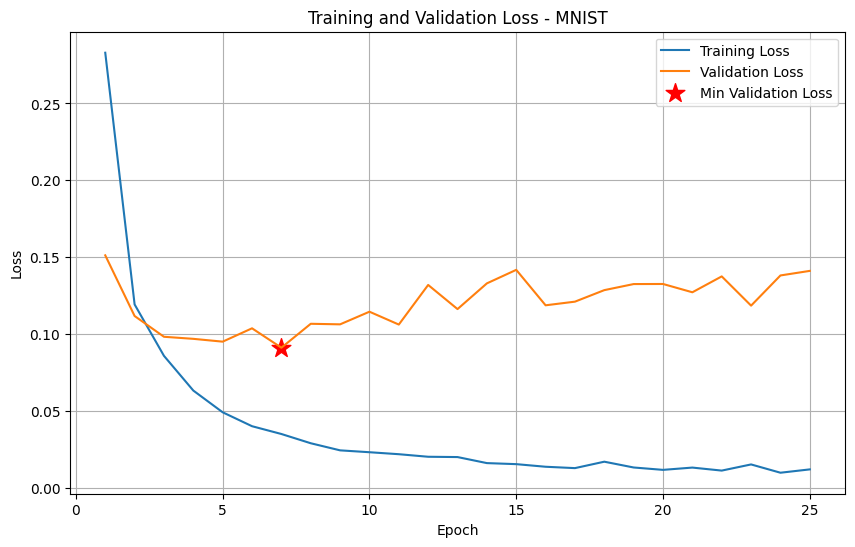

 - Accuracy: 0.9771
 - Precision: 0.9773
 - Recall: 0.9771
 - F1 Score: 0.9771


Training on CIFAR10 dataset
Epoch [1/25], Loss: 1.6715, Val Loss: 1.5908
Epoch [2/25], Loss: 1.4692, Val Loss: 1.5171
Epoch [3/25], Loss: 1.3697, Val Loss: 1.4998
Epoch [4/25], Loss: 1.2970, Val Loss: 1.4733
Epoch [5/25], Loss: 1.2316, Val Loss: 1.4705
Epoch [6/25], Loss: 1.1687, Val Loss: 1.4905
Epoch [7/25], Loss: 1.1174, Val Loss: 1.4822
Epoch [8/25], Loss: 1.0636, Val Loss: 1.4944
Epoch [9/25], Loss: 1.0154, Val Loss: 1.5364
Epoch [10/25], Loss: 0.9750, Val Loss: 1.5630
Epoch [11/25], Loss: 0.9292, Val Loss: 1.5865
Epoch [12/25], Loss: 0.8915, Val Loss: 1.6228
Epoch [13/25], Loss: 0.8539, Val Loss: 1.6616
Epoch [14/25], Loss: 0.8108, Val Loss: 1.7306
Epoch [15/25], Loss: 0.7805, Val Loss: 1.7961
Epoch [16/25], Loss: 0.7466, Val Loss: 1.8242
Epoch [17/25], Loss: 0.7151, Val Loss: 1.8874
Epoch [18/25], Loss: 0.6911, Val Loss: 1.9456
Epoch [19/25], Loss: 0.6665, Val Loss: 2.0361
Epoch [20/25], Loss: 0.637

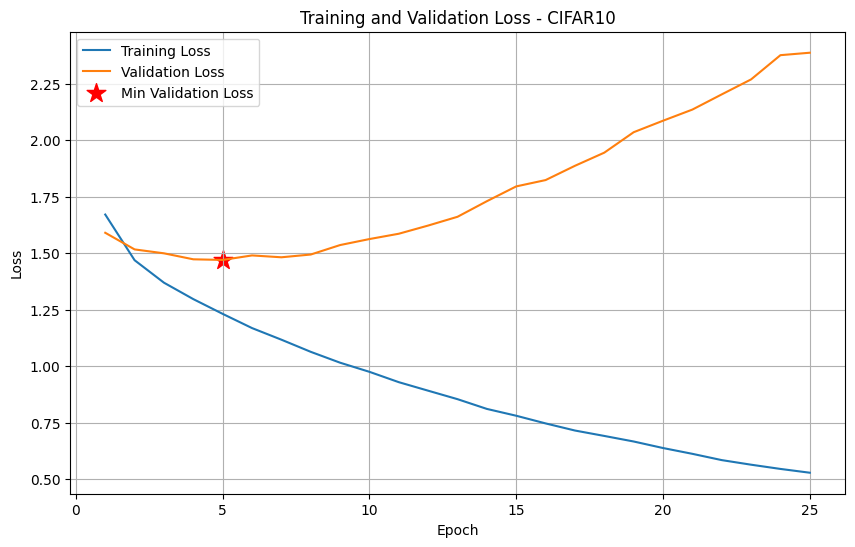

 - Accuracy: 0.5119
 - Precision: 0.5105
 - Recall: 0.5119
 - F1 Score: 0.5069


Training on AIRLINE dataset
Epoch [1/600], Loss: 0.5306, Val Loss: 0.4551
Epoch [2/600], Loss: 0.3854, Val Loss: 0.3304
Epoch [3/600], Loss: 0.2933, Val Loss: 0.2519
Epoch [4/600], Loss: 0.2429, Val Loss: 0.2037
Epoch [5/600], Loss: 0.2142, Val Loss: 0.1687
Epoch [6/600], Loss: 0.1857, Val Loss: 0.1440
Epoch [7/600], Loss: 0.1608, Val Loss: 0.1315
Epoch [8/600], Loss: 0.1434, Val Loss: 0.1253
Epoch [9/600], Loss: 0.1317, Val Loss: 0.1178
Epoch [10/600], Loss: 0.1219, Val Loss: 0.1081
Epoch [11/600], Loss: 0.1115, Val Loss: 0.0968
Epoch [12/600], Loss: 0.1010, Val Loss: 0.0845
Epoch [13/600], Loss: 0.0891, Val Loss: 0.0725
Epoch [14/600], Loss: 0.0784, Val Loss: 0.0617
Epoch [15/600], Loss: 0.0699, Val Loss: 0.0517
Epoch [16/600], Loss: 0.0614, Val Loss: 0.0373
Epoch [17/600], Loss: 0.0503, Val Loss: 0.0257
Epoch [18/600], Loss: 0.0422, Val Loss: 0.0204
Epoch [19/600], Loss: 0.0372, Val Loss: 0.0177
Epoch [

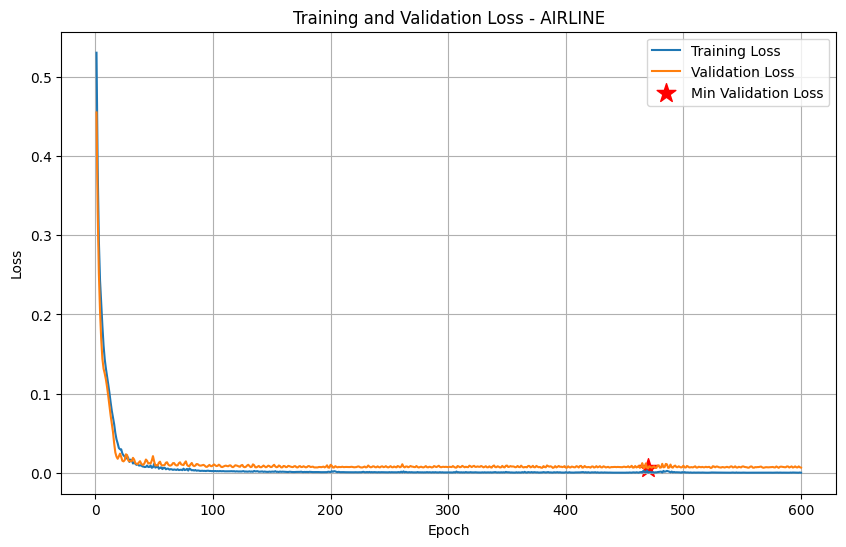

 - Mean Squared Error: 0.1239
 - R² Score: 0.6741


Training on ADULT dataset
Epoch [1/80], Loss: 0.3456, Val Loss: 0.3152
Epoch [2/80], Loss: 0.3098, Val Loss: 0.3130
Epoch [3/80], Loss: 0.3049, Val Loss: 0.3154
Epoch [4/80], Loss: 0.3008, Val Loss: 0.3158
Epoch [5/80], Loss: 0.2962, Val Loss: 0.3192
Epoch [6/80], Loss: 0.2940, Val Loss: 0.3143
Epoch [7/80], Loss: 0.2890, Val Loss: 0.3173
Epoch [8/80], Loss: 0.2861, Val Loss: 0.3192
Epoch [9/80], Loss: 0.2819, Val Loss: 0.3225
Epoch [10/80], Loss: 0.2783, Val Loss: 0.3195
Epoch [11/80], Loss: 0.2737, Val Loss: 0.3243
Epoch [12/80], Loss: 0.2687, Val Loss: 0.3406
Epoch [13/80], Loss: 0.2631, Val Loss: 0.3322
Epoch [14/80], Loss: 0.2586, Val Loss: 0.3483
Epoch [15/80], Loss: 0.2553, Val Loss: 0.3438
Epoch [16/80], Loss: 0.2501, Val Loss: 0.3407
Epoch [17/80], Loss: 0.2446, Val Loss: 0.3498
Epoch [18/80], Loss: 0.2407, Val Loss: 0.3637
Epoch [19/80], Loss: 0.2351, Val Loss: 0.3869
Epoch [20/80], Loss: 0.2315, Val Loss: 0.3865
Epoch [21/8

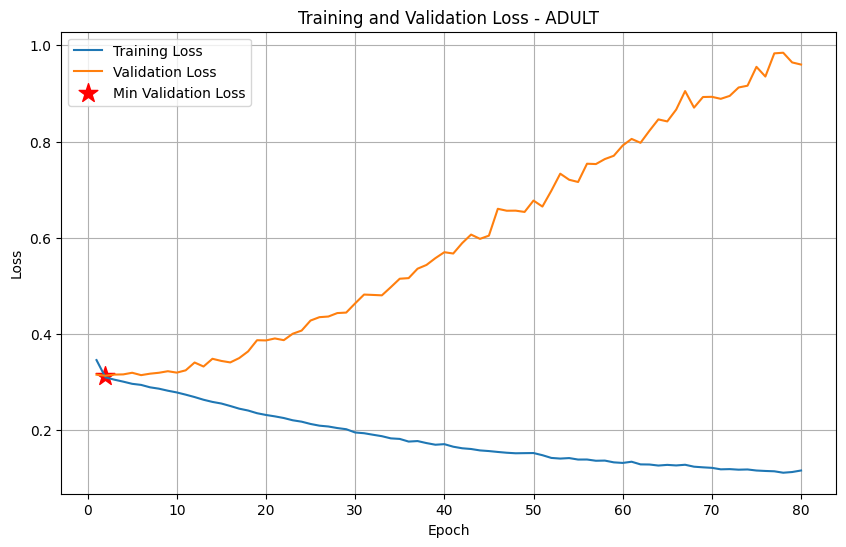

 - Accuracy: 0.8607
 - Precision: 0.8549
 - Recall: 0.8607
 - F1 Score: 0.8542


Training on LSST dataset
Epoch [1/100], Loss: 16.2224, Val Loss: 7.7906
Epoch [2/100], Loss: 5.4243, Val Loss: 6.6919
Epoch [3/100], Loss: 3.7397, Val Loss: 5.5457
Epoch [4/100], Loss: 2.3880, Val Loss: 4.1396
Epoch [5/100], Loss: 3.7097, Val Loss: 3.1351
Epoch [6/100], Loss: 1.8697, Val Loss: 2.6430
Epoch [7/100], Loss: 1.4897, Val Loss: 2.3388
Epoch [8/100], Loss: 1.2983, Val Loss: 2.2931
Epoch [9/100], Loss: 1.3722, Val Loss: 2.8831
Epoch [10/100], Loss: 1.3182, Val Loss: 2.2962
Epoch [11/100], Loss: 1.2876, Val Loss: 2.7240
Epoch [12/100], Loss: 1.7999, Val Loss: 2.4779
Epoch [13/100], Loss: 1.4414, Val Loss: 2.5419
Epoch [14/100], Loss: 1.1212, Val Loss: 2.3350
Epoch [15/100], Loss: 0.9772, Val Loss: 2.3252
Epoch [16/100], Loss: 0.9958, Val Loss: 2.7081
Epoch [17/100], Loss: 1.6083, Val Loss: 4.5746
Epoch [18/100], Loss: 3.0880, Val Loss: 13.3859
Epoch [19/100], Loss: 2.9724, Val Loss: 7.2268
Epoch [2

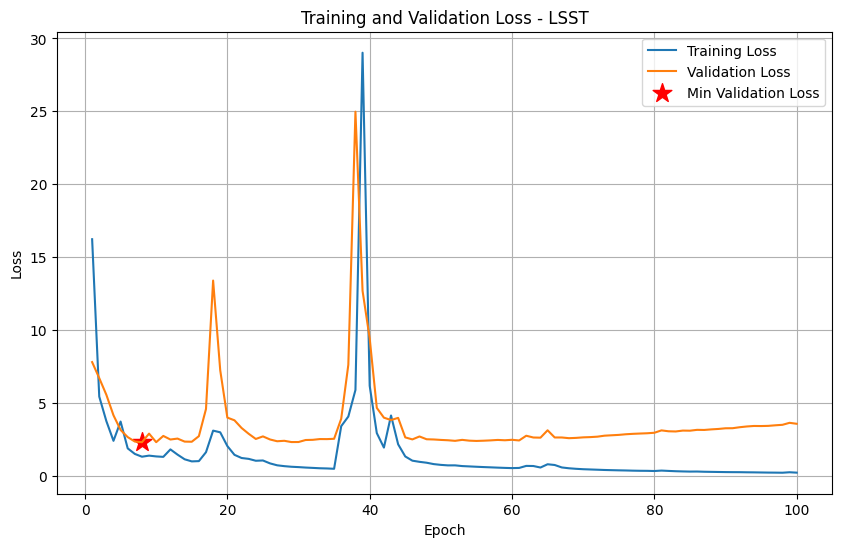

 - Accuracy: 0.4591
 - Precision: 0.4360
 - Recall: 0.4591
 - F1 Score: 0.4387


In [3]:
# Training loop
DATASETS = ['mnist', 'cifar10', 'airline', 'adult', 'LSST']
EPOCHS = [25,25,600,80,100]
BATCH_SIZE = 64
LEARNING_RATE = 0.001
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = MLP(dataset_name=dataset).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")

# 3.1) Simple Convolutional Neural Network (CNN)

MPS is available


Training on MNIST dataset
Epoch [1/150], Loss: 1.0805, Val Loss: 0.5969
Epoch [2/150], Loss: 0.4991, Val Loss: 0.4298
Epoch [3/150], Loss: 0.3840, Val Loss: 0.3517
Epoch [4/150], Loss: 0.3236, Val Loss: 0.3095
Epoch [5/150], Loss: 0.2884, Val Loss: 0.2816
Epoch [6/150], Loss: 0.2647, Val Loss: 0.2633
Epoch [7/150], Loss: 0.2471, Val Loss: 0.2483
Epoch [8/150], Loss: 0.2335, Val Loss: 0.2375
Epoch [9/150], Loss: 0.2224, Val Loss: 0.2274
Epoch [10/150], Loss: 0.2127, Val Loss: 0.2205
Epoch [11/150], Loss: 0.2046, Val Loss: 0.2116
Epoch [12/150], Loss: 0.1976, Val Loss: 0.2068
Epoch [13/150], Loss: 0.1908, Val Loss: 0.2014
Epoch [14/150], Loss: 0.1854, Val Loss: 0.1969
Epoch [15/150], Loss: 0.1804, Val Loss: 0.1938
Epoch [16/150], Loss: 0.1760, Val Loss: 0.1873
Epoch [17/150], Loss: 0.1723, Val Loss: 0.1823
Epoch [18/150], Loss: 0.1679, Val Loss: 0.1824
Epoch [19/150], Loss: 0.1648, Val Loss: 0.1797
Epoch [20/150], Loss: 0.1615, Val Loss: 0.1786
Epoch [21/150], Loss: 0.

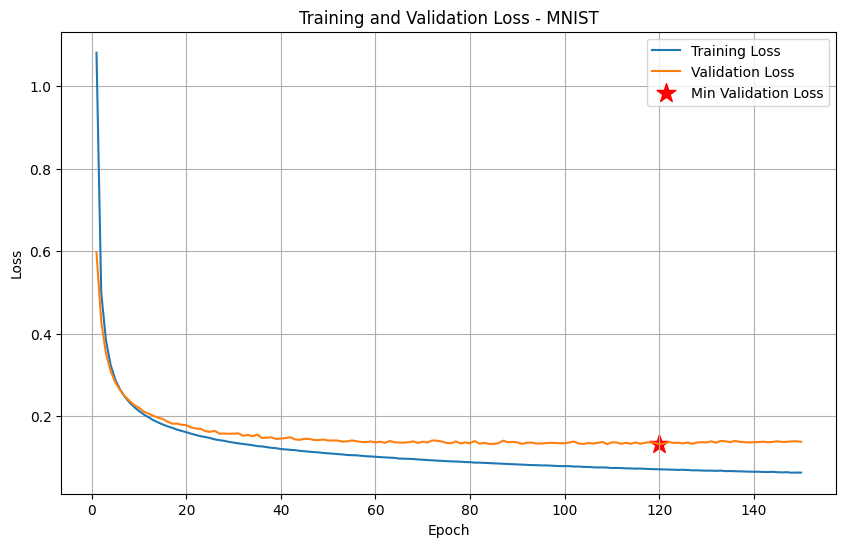

 - Accuracy: 0.9613
 - Precision: 0.9614
 - Recall: 0.9613
 - F1 Score: 0.9613


Training on CIFAR10 dataset
Epoch [1/150], Loss: 2.0392, Val Loss: 1.8929
Epoch [2/150], Loss: 1.8143, Val Loss: 1.7804
Epoch [3/150], Loss: 1.7304, Val Loss: 1.7311
Epoch [4/150], Loss: 1.6781, Val Loss: 1.6882
Epoch [5/150], Loss: 1.6414, Val Loss: 1.6629
Epoch [6/150], Loss: 1.6155, Val Loss: 1.6411
Epoch [7/150], Loss: 1.5929, Val Loss: 1.6277
Epoch [8/150], Loss: 1.5769, Val Loss: 1.6091
Epoch [9/150], Loss: 1.5594, Val Loss: 1.5997
Epoch [10/150], Loss: 1.5466, Val Loss: 1.5840
Epoch [11/150], Loss: 1.5330, Val Loss: 1.5765
Epoch [12/150], Loss: 1.5211, Val Loss: 1.5641
Epoch [13/150], Loss: 1.5093, Val Loss: 1.5488
Epoch [14/150], Loss: 1.4983, Val Loss: 1.5405
Epoch [15/150], Loss: 1.4884, Val Loss: 1.5293
Epoch [16/150], Loss: 1.4784, Val Loss: 1.5316
Epoch [17/150], Loss: 1.4692, Val Loss: 1.5193
Epoch [18/150], Loss: 1.4618, Val Loss: 1.5115
Epoch [19/150], Loss: 1.4535, Val Loss: 1.5062
Epoch [

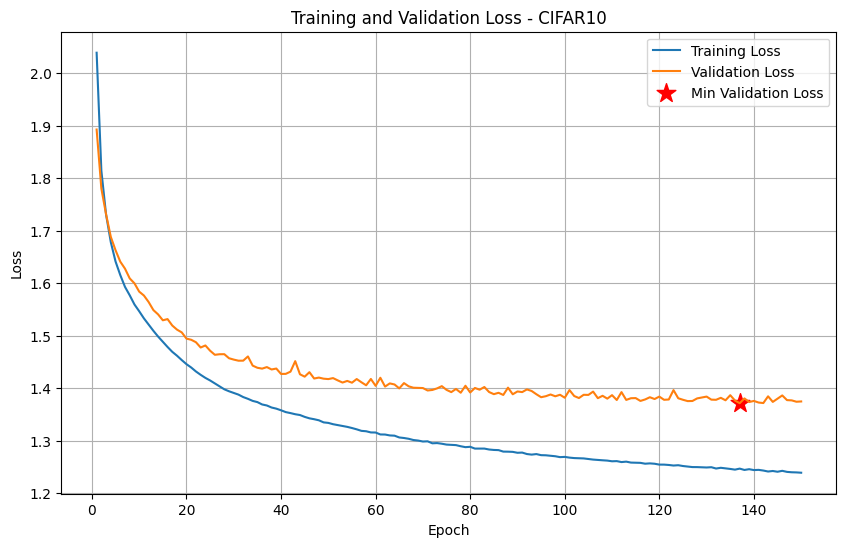

 - Accuracy: 0.5227
 - Precision: 0.5201
 - Recall: 0.5227
 - F1 Score: 0.5201


Training on AIRLINE dataset


RuntimeError: Given input size: (16x30x1). Calculated output size: (16x15x0). Output size is too small

In [5]:
# Training loop
DATASETS = ['mnist', 'cifar10', 'LSST']
EPOCHS = [150,150, 100]
BATCH_SIZE = 64
LEARNING_RATE = 0.001
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = CNN(dataset_name=dataset).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")

MPS is available


Training on LSST dataset
Epoch [1/150], Loss: 7.9790, Val Loss: 5.4678
Epoch [2/150], Loss: 4.4736, Val Loss: 4.6989
Epoch [3/150], Loss: 3.3987, Val Loss: 4.3246
Epoch [4/150], Loss: 2.9439, Val Loss: 3.9929
Epoch [5/150], Loss: 2.7027, Val Loss: 3.7398
Epoch [6/150], Loss: 2.5687, Val Loss: 3.5290
Epoch [7/150], Loss: 2.4523, Val Loss: 3.3467
Epoch [8/150], Loss: 2.3850, Val Loss: 3.5020
Epoch [9/150], Loss: 2.3501, Val Loss: 3.3169
Epoch [10/150], Loss: 2.3770, Val Loss: 3.1594
Epoch [11/150], Loss: 2.3468, Val Loss: 3.1256
Epoch [12/150], Loss: 2.3434, Val Loss: 3.2958
Epoch [13/150], Loss: 2.3790, Val Loss: 3.3935
Epoch [14/150], Loss: 2.3897, Val Loss: 3.0465
Epoch [15/150], Loss: 2.2487, Val Loss: 2.9649
Epoch [16/150], Loss: 2.1866, Val Loss: 2.9850
Epoch [17/150], Loss: 2.1768, Val Loss: 3.1296
Epoch [18/150], Loss: 2.1248, Val Loss: 3.0901
Epoch [19/150], Loss: 2.3317, Val Loss: 3.2184
Epoch [20/150], Loss: 2.2667, Val Loss: 2.8958
Epoch [21/150], Loss: 2.1

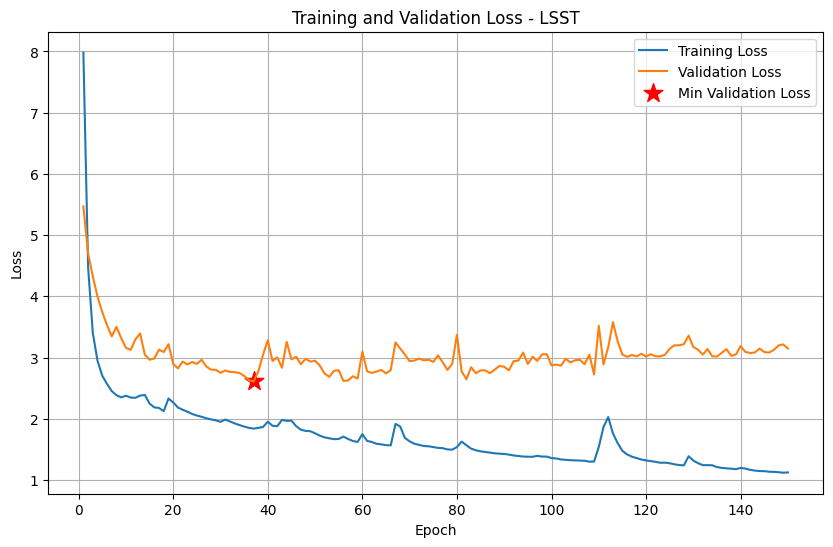

 - Accuracy: 0.4369
 - Precision: 0.4808
 - Recall: 0.4369
 - F1 Score: 0.3555


In [6]:
# Training loop
DATASETS = ['LSST']
EPOCHS = [ 150]
BATCH_SIZE = 64
LEARNING_RATE = 0.001
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = CNN(dataset_name=dataset).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")

## 3.2) Convolutional Neural Network (CNN) - LeNet5

MPS is available


Training on MNIST dataset
Epoch [1/150], Loss: 1.3372, Val Loss: 0.8255
Epoch [2/150], Loss: 0.6847, Val Loss: 0.5806
Epoch [3/150], Loss: 0.5210, Val Loss: 0.4647
Epoch [4/150], Loss: 0.4307, Val Loss: 0.3966
Epoch [5/150], Loss: 0.3706, Val Loss: 0.3481
Epoch [6/150], Loss: 0.3287, Val Loss: 0.3181
Epoch [7/150], Loss: 0.2984, Val Loss: 0.2948
Epoch [8/150], Loss: 0.2749, Val Loss: 0.2702
Epoch [9/150], Loss: 0.2562, Val Loss: 0.2564
Epoch [10/150], Loss: 0.2418, Val Loss: 0.2431
Epoch [11/150], Loss: 0.2298, Val Loss: 0.2311
Epoch [12/150], Loss: 0.2197, Val Loss: 0.2299
Epoch [13/150], Loss: 0.2104, Val Loss: 0.2181
Epoch [14/150], Loss: 0.2025, Val Loss: 0.2120
Epoch [15/150], Loss: 0.1957, Val Loss: 0.2063
Epoch [16/150], Loss: 0.1891, Val Loss: 0.2000
Epoch [17/150], Loss: 0.1844, Val Loss: 0.1966
Epoch [18/150], Loss: 0.1793, Val Loss: 0.1924
Epoch [19/150], Loss: 0.1744, Val Loss: 0.1984
Epoch [20/150], Loss: 0.1707, Val Loss: 0.1936
Epoch [21/150], Loss: 0.

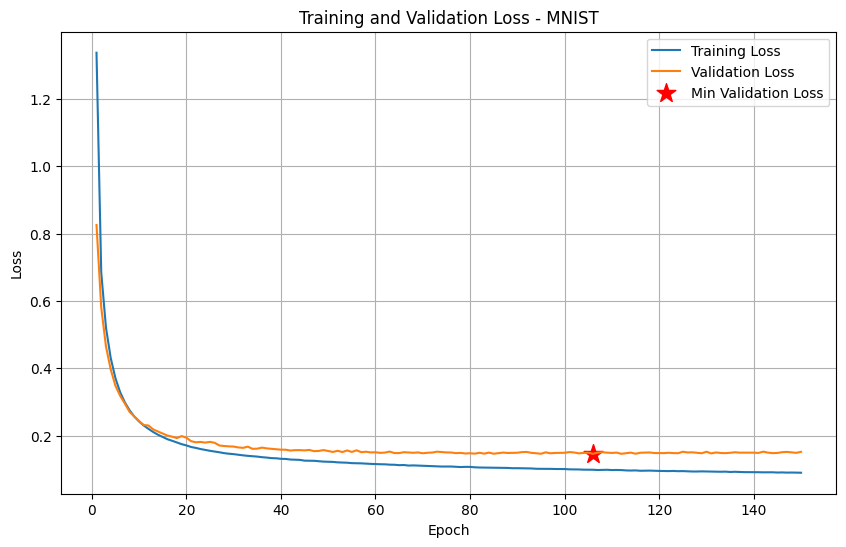

 - Accuracy: 0.9623
 - Precision: 0.9624
 - Recall: 0.9623
 - F1 Score: 0.9623


Training on CIFAR10 dataset
Epoch [1/300], Loss: 2.2102, Val Loss: 2.1582
Epoch [2/300], Loss: 2.1328, Val Loss: 2.1176
Epoch [3/300], Loss: 2.0980, Val Loss: 2.0907
Epoch [4/300], Loss: 2.0735, Val Loss: 2.0720
Epoch [5/300], Loss: 2.0439, Val Loss: 2.0348
Epoch [6/300], Loss: 2.0122, Val Loss: 2.0092
Epoch [7/300], Loss: 1.9888, Val Loss: 1.9888
Epoch [8/300], Loss: 1.9683, Val Loss: 1.9715
Epoch [9/300], Loss: 1.9508, Val Loss: 1.9591
Epoch [10/300], Loss: 1.9348, Val Loss: 1.9451
Epoch [11/300], Loss: 1.9224, Val Loss: 1.9318
Epoch [12/300], Loss: 1.9120, Val Loss: 1.9281
Epoch [13/300], Loss: 1.9032, Val Loss: 1.9177
Epoch [14/300], Loss: 1.8953, Val Loss: 1.9136
Epoch [15/300], Loss: 1.8882, Val Loss: 1.9024
Epoch [16/300], Loss: 1.8821, Val Loss: 1.8977
Epoch [17/300], Loss: 1.8762, Val Loss: 1.8976
Epoch [18/300], Loss: 1.8708, Val Loss: 1.8934
Epoch [19/300], Loss: 1.8674, Val Loss: 1.8888
Epoch [

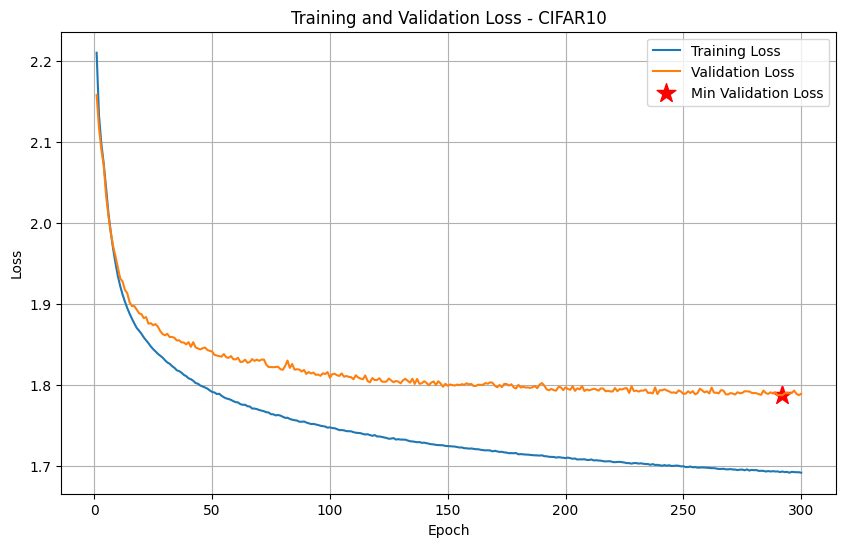

 - Accuracy: 0.3729
 - Precision: 0.3987
 - Recall: 0.3729
 - F1 Score: 0.3699


Training on ADULT dataset


RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [64, 1, 1, 1, 105]

In [7]:
# Training loop
DATASETS = ['mnist', 'cifar10']
EPOCHS = [150,300]
BATCH_SIZE = 64
LEARNING_RATE = 0.001
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = LeNet5Flexible(dataset_name=dataset).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")

## 3.3) Convolutional Neural Network (CNN) - ResNet 9

MPS is available


Training on MNIST dataset
Epoch [1/25], Loss: 0.1113, Val Loss: 0.0399
Epoch [2/25], Loss: 0.0401, Val Loss: 0.0368
Epoch [3/25], Loss: 0.0268, Val Loss: 0.0419
Epoch [4/25], Loss: 0.0219, Val Loss: 0.0470
Epoch [5/25], Loss: 0.0173, Val Loss: 0.0382
Epoch [6/25], Loss: 0.0156, Val Loss: 0.0593
Epoch [7/25], Loss: 0.0133, Val Loss: 0.0371
Epoch [8/25], Loss: 0.0102, Val Loss: 0.0371
Epoch [9/25], Loss: 0.0122, Val Loss: 0.0506
Epoch [10/25], Loss: 0.0077, Val Loss: 0.0309
Epoch [11/25], Loss: 0.0098, Val Loss: 0.0340
Epoch [12/25], Loss: 0.0077, Val Loss: 0.0507
Epoch [13/25], Loss: 0.0041, Val Loss: 0.0364
Epoch [14/25], Loss: 0.0053, Val Loss: 0.0672
Epoch [15/25], Loss: 0.0072, Val Loss: 0.0350
Epoch [16/25], Loss: 0.0052, Val Loss: 0.0410
Epoch [17/25], Loss: 0.0051, Val Loss: 0.0423
Epoch [18/25], Loss: 0.0036, Val Loss: 0.0489
Epoch [19/25], Loss: 0.0042, Val Loss: 0.0379
Epoch [20/25], Loss: 0.0062, Val Loss: 0.0385
Epoch [21/25], Loss: 0.0017, Val Loss: 0.037

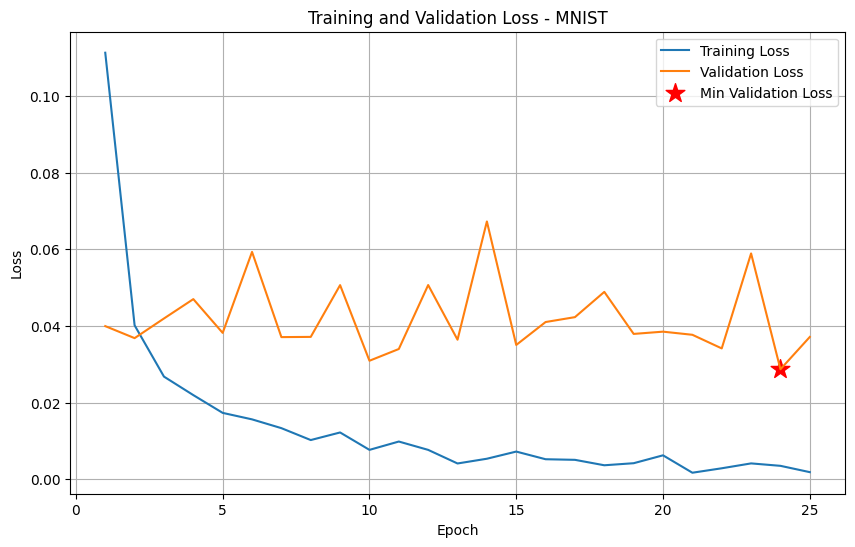

 - Accuracy: 0.9927
 - Precision: 0.9927
 - Recall: 0.9927
 - F1 Score: 0.9927


Training on CIFAR10 dataset
Epoch [1/25], Loss: 1.2871, Val Loss: 1.0318
Epoch [2/25], Loss: 0.8514, Val Loss: 0.8933
Epoch [3/25], Loss: 0.6461, Val Loss: 0.6802
Epoch [4/25], Loss: 0.4917, Val Loss: 0.6277
Epoch [5/25], Loss: 0.3562, Val Loss: 0.7547
Epoch [6/25], Loss: 0.2331, Val Loss: 0.6800
Epoch [7/25], Loss: 0.1523, Val Loss: 0.7811
Epoch [8/25], Loss: 0.1052, Val Loss: 0.7493
Epoch [9/25], Loss: 0.0817, Val Loss: 0.8139
Epoch [10/25], Loss: 0.0707, Val Loss: 0.8912
Epoch [11/25], Loss: 0.0616, Val Loss: 0.9903
Epoch [12/25], Loss: 0.0542, Val Loss: 0.9569
Epoch [13/25], Loss: 0.0523, Val Loss: 1.0663
Epoch [14/25], Loss: 0.0513, Val Loss: 0.9654
Epoch [15/25], Loss: 0.0357, Val Loss: 1.0300
Epoch [16/25], Loss: 0.0407, Val Loss: 1.0675
Epoch [17/25], Loss: 0.0401, Val Loss: 1.0115
Epoch [18/25], Loss: 0.0339, Val Loss: 1.1271
Epoch [19/25], Loss: 0.0308, Val Loss: 1.1271
Epoch [20/25], Loss: 0.034

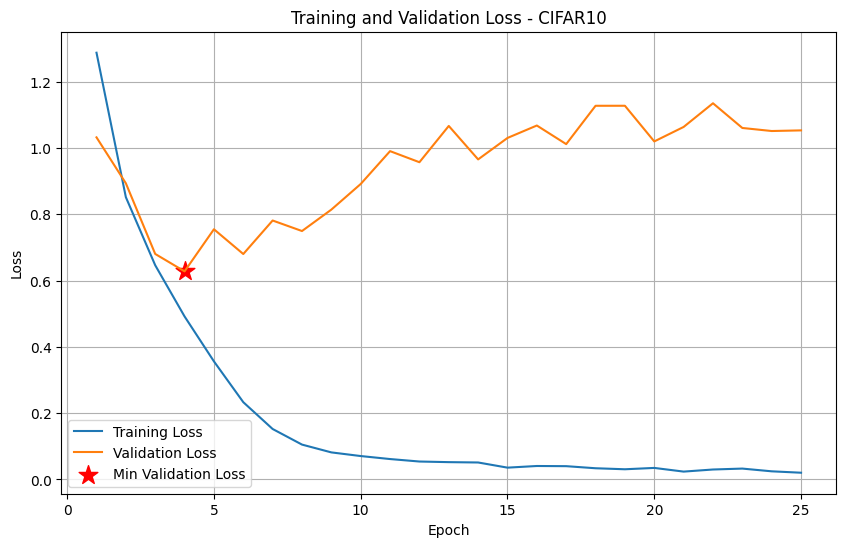

 - Accuracy: 0.8050
 - Precision: 0.8040
 - Recall: 0.8050
 - F1 Score: 0.8029


In [ ]:
# Training loop
DATASETS = ['mnist', 'cifar10', 'LSST'] # accuracy on lsst 53.5%
EPOCHS = [30, 30, 60]
BATCH_SIZE = 64
LEARNING_RATE = 0.001
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = ResNet9(dataset_name=dataset).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")

## 4) Transformer

MPS is available


Training on AIRLINE dataset
Epoch [1/600], Loss: 1.5058, Val Loss: 1.4213
Epoch [2/600], Loss: 1.1164, Val Loss: 1.0281
Epoch [3/600], Loss: 1.0862, Val Loss: 0.4579
Epoch [4/600], Loss: 0.5064, Val Loss: 0.1810
Epoch [5/600], Loss: 0.2079, Val Loss: 0.4144
Epoch [6/600], Loss: 0.3648, Val Loss: 0.3399
Epoch [7/600], Loss: 0.3021, Val Loss: 0.1945
Epoch [8/600], Loss: 0.1958, Val Loss: 0.1393
Epoch [9/600], Loss: 0.1778, Val Loss: 0.1450
Epoch [10/600], Loss: 0.1833, Val Loss: 0.1391
Epoch [11/600], Loss: 0.1690, Val Loss: 0.1304
Epoch [12/600], Loss: 0.1474, Val Loss: 0.1471
Epoch [13/600], Loss: 0.1397, Val Loss: 0.1920
Epoch [14/600], Loss: 0.1619, Val Loss: 0.1971
Epoch [15/600], Loss: 0.1617, Val Loss: 0.1678
Epoch [16/600], Loss: 0.1475, Val Loss: 0.1471
Epoch [17/600], Loss: 0.1419, Val Loss: 0.1342
Epoch [18/600], Loss: 0.1333, Val Loss: 0.1248
Epoch [19/600], Loss: 0.1312, Val Loss: 0.1254
Epoch [20/600], Loss: 0.1344, Val Loss: 0.1273
Epoch [21/600], Loss: 

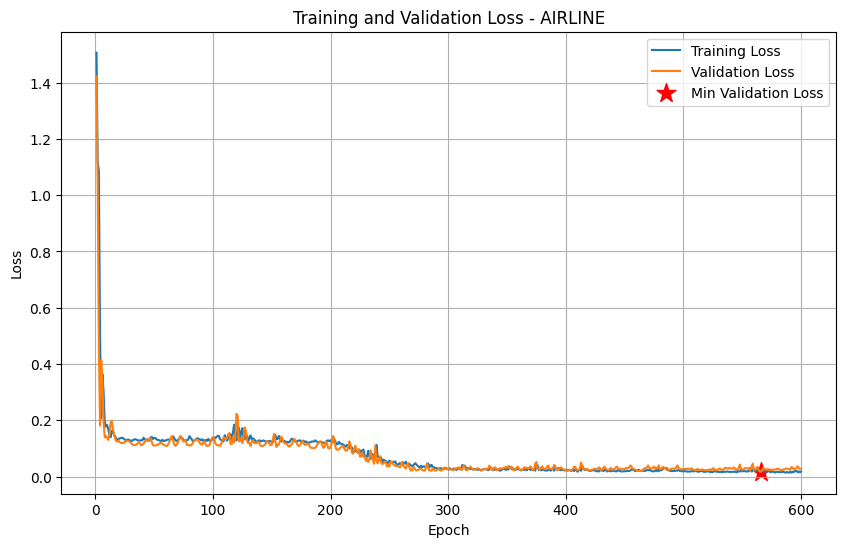

 - Mean Squared Error: 0.6485
 - R² Score: -0.7060


Training on ADULT dataset


/Users/dariofenoglio/miniforge3/envs/eris/lib/python3.10/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch [1/80], Loss: 0.5329, Val Loss: 0.4758
Epoch [2/80], Loss: 0.4440, Val Loss: 0.4197
Epoch [3/80], Loss: 0.4200, Val Loss: 0.3784
Epoch [4/80], Loss: 0.3828, Val Loss: 0.3662
Epoch [5/80], Loss: 0.3817, Val Loss: 0.3622
Epoch [6/80], Loss: 0.3649, Val Loss: 0.3487
Epoch [7/80], Loss: 0.3563, Val Loss: 0.3446
Epoch [8/80], Loss: 0.3528, Val Loss: 0.3496
Epoch [9/80], Loss: 0.3507, Val Loss: 0.3453
Epoch [10/80], Loss: 0.3538, Val Loss: 0.3513
Epoch [11/80], Loss: 0.3527, Val Loss: 0.3448
Epoch [12/80], Loss: 0.3515, Val Loss: 0.3422
Epoch [13/80], Loss: 0.3476, Val Loss: 0.3448
Epoch [14/80], Loss: 0.3512, Val Loss: 0.3465
Epoch [15/80], Loss: 0.3443, Val Loss: 0.3432
Epoch [16/80], Loss: 0.3445, Val Loss: 0.3404
Epoch [17/80], Loss: 0.3447, Val Loss: 0.3421
Epoch [18/80], Loss: 0.3446, Val Loss: 0.3390
Epoch [19/80], Loss: 0.3451, Val Loss: 0.3389
Epoch [20/80], Loss: 0.3427, Val Loss: 0.3435
Epoch [21/80], Loss: 0.3446, Val Loss: 0.3377
Epoch [22/80], Loss: 0.3437, Val Loss: 0.33

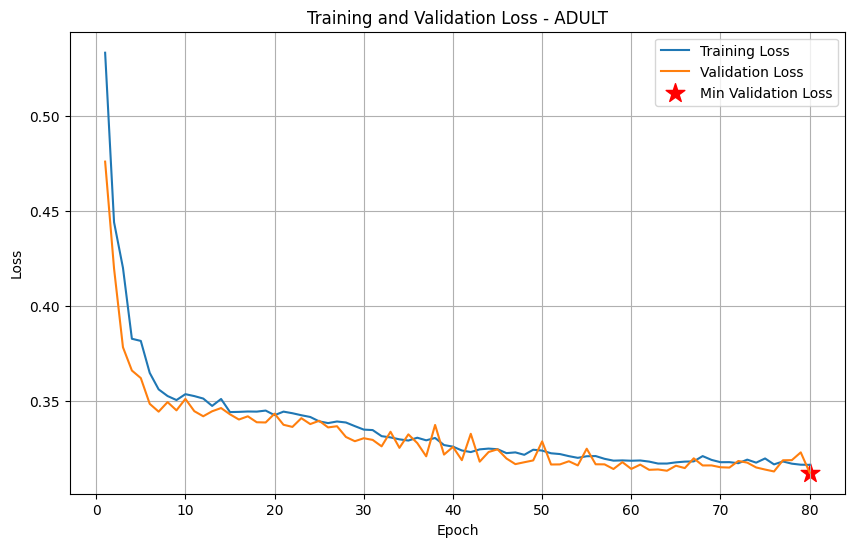

 - Accuracy: 0.8574
 - Precision: 0.8516
 - Recall: 0.8574
 - F1 Score: 0.8526


Training on LSST dataset


/Users/dariofenoglio/miniforge3/envs/eris/lib/python3.10/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch [1/600], Loss: 2.0664, Val Loss: 1.9444
Epoch [2/600], Loss: 1.9418, Val Loss: 1.8533
Epoch [3/600], Loss: 1.8437, Val Loss: 1.7857
Epoch [4/600], Loss: 1.8140, Val Loss: 1.7209
Epoch [5/600], Loss: 1.7358, Val Loss: 1.6447
Epoch [6/600], Loss: 1.6594, Val Loss: 1.5999
Epoch [7/600], Loss: 1.6198, Val Loss: 1.5927
Epoch [8/600], Loss: 1.5992, Val Loss: 1.5173
Epoch [9/600], Loss: 1.5638, Val Loss: 1.4769
Epoch [10/600], Loss: 1.5105, Val Loss: 1.5099
Epoch [11/600], Loss: 1.5750, Val Loss: 1.5531
Epoch [12/600], Loss: 1.5254, Val Loss: 1.4382
Epoch [13/600], Loss: 1.4687, Val Loss: 1.4241
Epoch [14/600], Loss: 1.4570, Val Loss: 1.4101
Epoch [15/600], Loss: 1.4476, Val Loss: 1.3963
Epoch [16/600], Loss: 1.4105, Val Loss: 1.3944
Epoch [17/600], Loss: 1.4626, Val Loss: 1.3894
Epoch [18/600], Loss: 1.4517, Val Loss: 1.3968
Epoch [19/600], Loss: 1.4647, Val Loss: 1.4084
Epoch [20/600], Loss: 1.4454, Val Loss: 1.3782
Epoch [21/600], Loss: 1.4031, Val Loss: 1.3518
Epoch [22/600], Loss: 

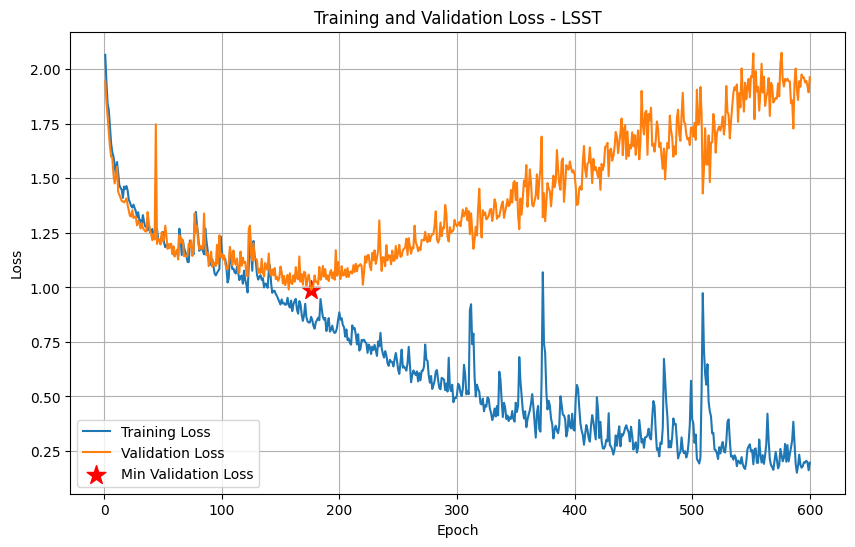

 - Accuracy: 0.5879
 - Precision: 0.5688
 - Recall: 0.5879
 - F1 Score: 0.5578


/Users/dariofenoglio/miniforge3/envs/eris/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
# Training loop
DATASETS = [ 'airline', 'adult', 'LSST']   
EPOCHS = [600,80, 600]
BATCH_SIZE = 64
LEARNING_RATE = 0.001 #higher performance on lsst with lr=0.0005
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = TransformerModelFlexible(dataset_name=dataset).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")

MPS is available


Training on LSST dataset


/Users/dariofenoglio/miniforge3/envs/eris/lib/python3.10/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch [1/600], Loss: 2.0289, Val Loss: 1.9627
Epoch [2/600], Loss: 1.9340, Val Loss: 1.8963
Epoch [3/600], Loss: 1.8919, Val Loss: 1.8796
Epoch [4/600], Loss: 1.8406, Val Loss: 1.8008
Epoch [5/600], Loss: 1.7967, Val Loss: 1.7238
Epoch [6/600], Loss: 1.7449, Val Loss: 1.6596
Epoch [7/600], Loss: 1.6917, Val Loss: 1.5864
Epoch [8/600], Loss: 1.6312, Val Loss: 1.5410
Epoch [9/600], Loss: 1.5923, Val Loss: 1.5167
Epoch [10/600], Loss: 1.5698, Val Loss: 1.5027
Epoch [11/600], Loss: 1.5675, Val Loss: 1.4769
Epoch [12/600], Loss: 1.5522, Val Loss: 1.4362
Epoch [13/600], Loss: 1.5130, Val Loss: 1.4428
Epoch [14/600], Loss: 1.5088, Val Loss: 1.4643
Epoch [15/600], Loss: 1.5048, Val Loss: 1.4072
Epoch [16/600], Loss: 1.4853, Val Loss: 1.4327
Epoch [17/600], Loss: 1.4997, Val Loss: 1.3748
Epoch [18/600], Loss: 1.4518, Val Loss: 1.3632
Epoch [19/600], Loss: 1.4637, Val Loss: 1.3459
Epoch [20/600], Loss: 1.4340, Val Loss: 1.2755
Epoch [21/600], Loss: 1.4296, Val Loss: 1.2927
Epoch [22/600], Loss: 

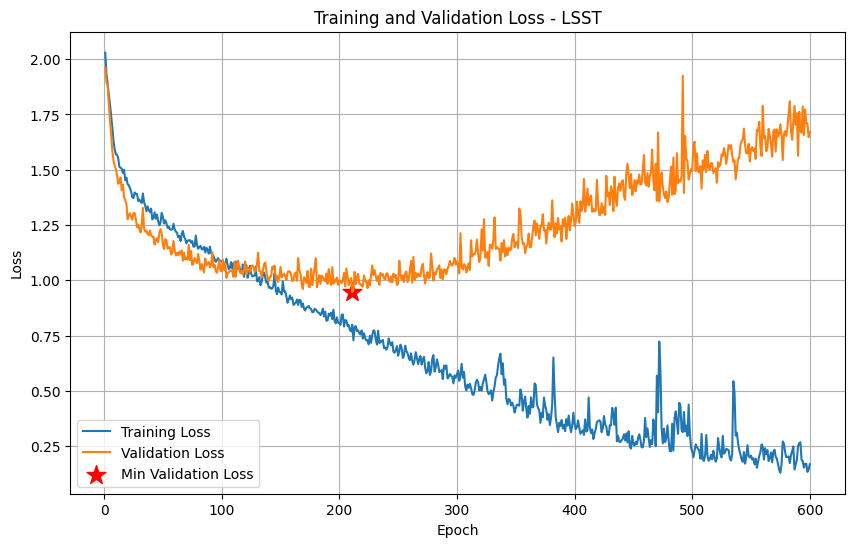

 - Accuracy: 0.5841
 - Precision: 0.5593
 - Recall: 0.5841
 - F1 Score: 0.5531


In [15]:
# Training loop
DATASETS = ['LSST']
EPOCHS = [600]
BATCH_SIZE = 64
LEARNING_RATE = 0.0005
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = TransformerModelFlexible(dataset_name=dataset, num_heads=2, num_layers=2, hidden_dim=64).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")

## 6) Long-Short Time Model (LSTM)

MPS is available


Training on AIRLINE dataset
Epoch [1/600], Loss: 0.4808, Val Loss: 0.4062
Epoch [2/600], Loss: 0.4678, Val Loss: 0.4000
Epoch [3/600], Loss: 0.4561, Val Loss: 0.3942
Epoch [4/600], Loss: 0.4449, Val Loss: 0.3859
Epoch [5/600], Loss: 0.4298, Val Loss: 0.3720
Epoch [6/600], Loss: 0.4122, Val Loss: 0.3520
Epoch [7/600], Loss: 0.3870, Val Loss: 0.3239
Epoch [8/600], Loss: 0.3515, Val Loss: 0.2834
Epoch [9/600], Loss: 0.3013, Val Loss: 0.2312
Epoch [10/600], Loss: 0.2480, Val Loss: 0.1780
Epoch [11/600], Loss: 0.1895, Val Loss: 0.1345
Epoch [12/600], Loss: 0.1569, Val Loss: 0.1178
Epoch [13/600], Loss: 0.1459, Val Loss: 0.1327
Epoch [14/600], Loss: 0.1727, Val Loss: 0.1566
Epoch [15/600], Loss: 0.1979, Val Loss: 0.1441
Epoch [16/600], Loss: 0.1860, Val Loss: 0.1229
Epoch [17/600], Loss: 0.1625, Val Loss: 0.1143
Epoch [18/600], Loss: 0.1467, Val Loss: 0.1193
Epoch [19/600], Loss: 0.1508, Val Loss: 0.1273
Epoch [20/600], Loss: 0.1514, Val Loss: 0.1346
Epoch [21/600], Loss: 

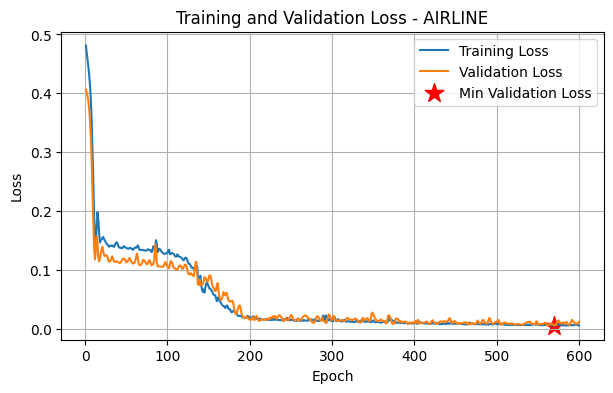

 - Mean Squared Error: 0.4243
 - R² Score: -0.1161


Training on ADULT dataset
Epoch [1/80], Loss: 0.5590, Val Loss: 0.5446
Epoch [2/80], Loss: 0.5548, Val Loss: 0.5453
Epoch [3/80], Loss: 0.5541, Val Loss: 0.5443
Epoch [4/80], Loss: 0.5543, Val Loss: 0.5469
Epoch [5/80], Loss: 0.5548, Val Loss: 0.5445
Epoch [6/80], Loss: 0.5541, Val Loss: 0.5443
Epoch [7/80], Loss: 0.5540, Val Loss: 0.5466
Epoch [8/80], Loss: 0.5534, Val Loss: 0.5468
Epoch [9/80], Loss: 0.5538, Val Loss: 0.5440
Epoch [10/80], Loss: 0.5535, Val Loss: 0.5438
Epoch [11/80], Loss: 0.5480, Val Loss: 0.5234
Epoch [12/80], Loss: 0.4998, Val Loss: 0.4806
Epoch [13/80], Loss: 0.5350, Val Loss: 0.5438
Epoch [14/80], Loss: 0.5532, Val Loss: 0.5444
Epoch [15/80], Loss: 0.5535, Val Loss: 0.5442
Epoch [16/80], Loss: 0.5533, Val Loss: 0.5434
Epoch [17/80], Loss: 0.5484, Val Loss: 0.5581
Epoch [18/80], Loss: 0.4800, Val Loss: 0.4413
Epoch [19/80], Loss: 0.4575, Val Loss: 0.4483
Epoch [20/80], Loss: 0.4538, Val Loss: 0.4569
Epoch [21/

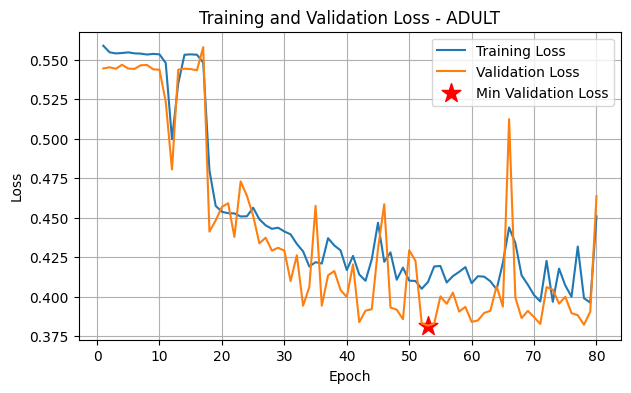

 - Accuracy: 0.8113
 - Precision: 0.7968
 - Recall: 0.8113
 - F1 Score: 0.7956


Training on LSST dataset


RuntimeError: input.size(-1) must be equal to input_size. Expected 1, got 6

In [4]:
# Training loop
DATASETS = ['airline', 'adult', 'LSST']   
EPOCHS = [600,80, 200]
BATCH_SIZE = 64
LEARNING_RATE = 0.001 #higher performance on lsst with lr=0.0005
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = MultiLayerLSTM(dataset_name=dataset).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")

# Scaling Model size
- 50K
- 188K
- 707M
- 2.66M
- 10M
- 37.6M

In [27]:
# MLP
hidden_dims = [64, 128, 256, 512, 1024, 2048]
n_layers = [1, 6, 9, 10, 10, 10]
for h, n in zip(hidden_dims, n_layers):
    model = ScalableMLP(dataset_name='mnist', hidden_dim=h, num_layers=n).to(DEVICE)
    num_params = sum(p.numel() for p in model.parameters())
    print(f'Hidden dimension: {h}, Number of layers: {n}, Number of parameters: {num_params}')

Hidden dimension: 64, Number of layers: 1, Number of parameters: 50890
Hidden dimension: 128, Number of layers: 6, Number of parameters: 184330
Hidden dimension: 256, Number of layers: 9, Number of parameters: 729866
Hidden dimension: 512, Number of layers: 10, Number of parameters: 2770954
Hidden dimension: 1024, Number of layers: 10, Number of parameters: 10260490
Hidden dimension: 2048, Number of layers: 10, Number of parameters: 39395338


In [16]:
# CNN
num_conv_layers=[2, 2, 2, 3, 4, 4]
base_filters=[52, 102, 198, 172, 163, 316] 
for b, n in zip(base_filters, num_conv_layers):
    model = ScalableCNN(dataset_name='mnist', base_filters=b, num_conv_layers=n).to(DEVICE)
    num_params = sum(p.numel() for p in model.parameters())
    print(f'Base filter: {b}, Number of conv layers: {n}, Number of parameters: {num_params}')

Base filter: 52, Number of conv layers: 2, Number of parameters: 49296
Base filter: 102, Number of conv layers: 2, Number of parameters: 188496
Base filter: 198, Number of conv layers: 2, Number of parameters: 708048
Base filter: 172, Number of conv layers: 3, Number of parameters: 2665312
Base filter: 163, Number of conv layers: 4, Number of parameters: 10046994
Base filter: 316, Number of conv layers: 4, Number of parameters: 37753152


## 1. Scalable MLP

MPS is available


Training on MNIST dataset
Epoch [1/5], Loss: 0.8974, Val Loss: 0.2817
Epoch [2/5], Loss: 0.2977, Val Loss: 0.2428
Epoch [3/5], Loss: 0.1987, Val Loss: 0.1716
Epoch [4/5], Loss: 0.1558, Val Loss: 0.1766
Epoch [5/5], Loss: 0.1578, Val Loss: 0.2120


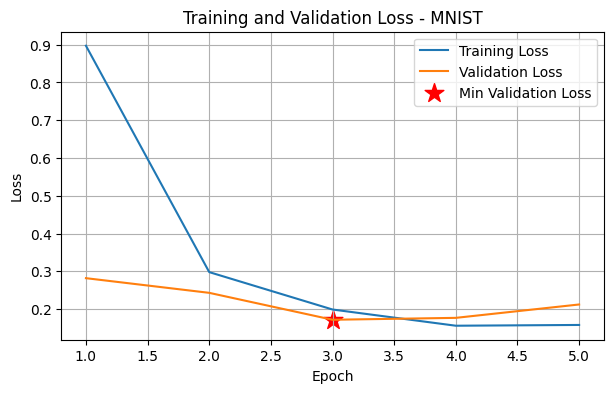

 - Accuracy: 0.9568
 - Precision: 0.9573
 - Recall: 0.9568
 - F1 Score: 0.9569


Training on ADULT dataset
Epoch [1/5], Loss: 0.3549, Val Loss: 0.3355
Epoch [2/5], Loss: 0.3308, Val Loss: 0.3227
Epoch [3/5], Loss: 0.3140, Val Loss: 0.3274
Epoch [4/5], Loss: 0.3075, Val Loss: 0.3499
Epoch [5/5], Loss: 0.3141, Val Loss: 0.3458


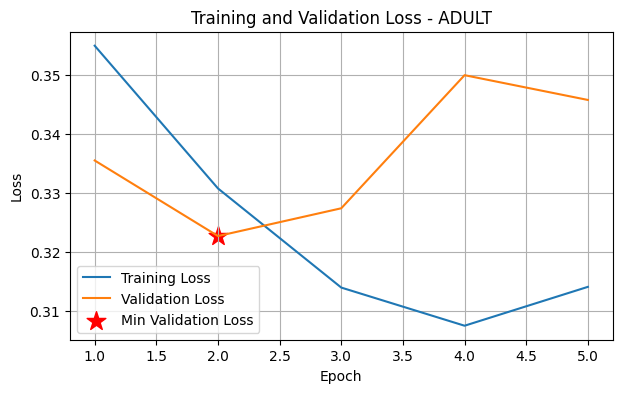

 - Accuracy: 0.8554
 - Precision: 0.8488
 - Recall: 0.8554
 - F1 Score: 0.8482


In [18]:
# Training loop
DATASETS = ['mnist','adult']   
EPOCHS = [5,5]
NUM_LAYERS = [2,4,6,8,10]
BATCH_SIZE = 64
LEARNING_RATE = 0.001 #higher performance on lsst with lr=0.0005
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = ScalableMLP(dataset_name=dataset, hidden_dim=1024, num_layers=10).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")

## 2. Scalable CNN

MPS is available


Training on MNIST dataset
Epoch [1/5], Loss: 0.1731, Val Loss: 0.0710
Epoch [2/5], Loss: 0.0426, Val Loss: 0.0669
Epoch [3/5], Loss: 0.0345, Val Loss: 0.0529
Epoch [4/5], Loss: 0.0243, Val Loss: 0.0439
Epoch [5/5], Loss: 0.0192, Val Loss: 0.0421


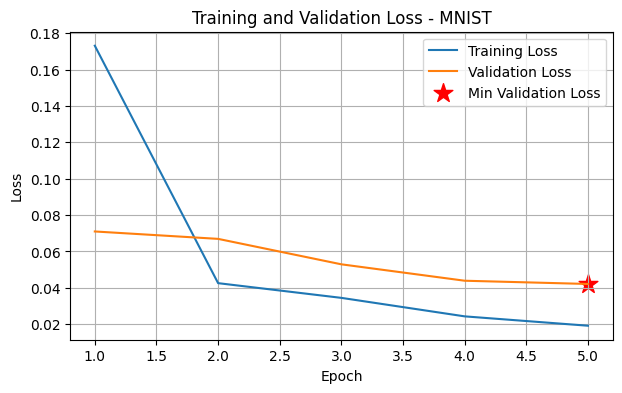

 - Accuracy: 0.9898
 - Precision: 0.9898
 - Recall: 0.9898
 - F1 Score: 0.9898


Training on CIFAR10 dataset


KeyboardInterrupt: 

In [17]:
# Training loop
DATASETS = ['mnist', 'cifar10']   
EPOCHS = [5,5]
NUM_LAYERS = [2,4,6,8,10]
BATCH_SIZE = 64
LEARNING_RATE = 0.001 #higher performance on lsst with lr=0.0005
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = ScalableCNN(dataset_name=dataset, base_filters=316, num_conv_layers=4).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")